# 9-Agent PatchCore Ensemble Pipeline
Extracts features using ResNet18 and computes nearest-neighbor distances to 9 independent memory banks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from tqdm.notebook import tqdm
import sys
import cv2

# Patch for pandas 2.0+
import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes
try:
    import pandas.core.indexes.base
    sys.modules['pandas.indexes.base'] = pandas.core.indexes.base
except ImportError: pass

## 1. Load Data

In [2]:
print("Loading LSWMD.pkl...")
with open('LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')

def extract_val(x):
    if type(x) == list or type(x).__name__ == 'ndarray':
        if len(x) > 0:
            if type(x[0]) == list or type(x[0]).__name__ == 'ndarray':
                if len(x[0]) > 0: return x[0][0]
                return None
            return x[0]
        return None
    return x

df['failureType'] = df['failureType'].apply(extract_val)
df['trianTestLabel'] = df['trianTestLabel'].apply(extract_val)
df = df.dropna(subset=['failureType'])

labels = df['failureType'].unique().tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}
idx_to_label = {i: l for i, l in enumerate(labels)}

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['failureType'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Loading LSWMD.pkl...


/var/folders/m_/4r8l9_rn6jng5pdc6lth0yhr0000gn/T/ipykernel_7631/2229378773.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Train samples: 155655, Test samples: 17295


## 2. PyTorch Dataset & DataLoaders

In [3]:
class WaferDataset(Dataset):
    def __init__(self, df, img_size=(128, 128)):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        wafer = self.df.loc[idx, 'waferMap']
        wafer_resized = cv2.resize(wafer, self.img_size, interpolation=cv2.INTER_NEAREST)
        
        rgb = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.float32)
        rgb[:, :, 0][wafer_resized == 1] = 1.0  
        rgb[:, :, 1][wafer_resized == 2] = 1.0  
        
        mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
        std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)
        rgb = (rgb - mean) / std
        
        img_tensor = torch.tensor(rgb, dtype=torch.float32).permute(2, 0, 1)
        label_str = self.df.loc[idx, 'failureType']
        return img_tensor, label_to_idx[label_str]

## 3. Define PatchCore Feature Extractor

In [4]:
class PatchCoreFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.layer2 = nn.Sequential(*list(resnet.children())[:6])
        self.layer3 = resnet.layer3
        for param in self.parameters():
            param.requires_grad = False
            
    def forward(self, x):
        feat2 = self.layer2(x)
        feat3 = self.layer3(feat2)
        
        feat2 = F.avg_pool2d(feat2, 3, 1, 1)
        feat3 = F.avg_pool2d(feat3, 3, 1, 1)
        
        feat2 = F.interpolate(feat2, size=feat3.shape[-2:], mode='bilinear', align_corners=False)
        out = torch.cat([feat2, feat3], dim=1)
        out = out.reshape(x.size(0), out.size(1), -1).transpose(1, 2)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
extractor = PatchCoreFeatureExtractor().to(device)
extractor.eval()
print(f"Using device: {device}")

Using device: mps


## 4. Build 9 Independent Memory Banks

In [5]:
memory_banks = {}

print("Building Memory Banks...")
for label in tqdm(labels):
    sub_df = train_df[train_df['failureType'] == label]
    if len(sub_df) == 0: continue
    
    ds = WaferDataset(sub_df, img_size=(128, 128))
    loader = DataLoader(ds, batch_size=16, shuffle=False)
    
    bank_features = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            feats = extractor(imgs) # (B, patches, C)
            feats = feats.reshape(-1, feats.size(-1)) # flatten batch and patches
            bank_features.append(feats.cpu())
            
    bank_tensor = torch.cat(bank_features, dim=0)
    
    # Subsample to limit memory usage (keep 3%)
    idx = torch.randperm(bank_tensor.size(0))[:max(1, int(bank_tensor.size(0)*0.03))]
    bank_tensor = bank_tensor[idx]
    
    memory_banks[label_to_idx[label]] = bank_tensor.to(device)
    print(f"[{label}] Memory Bank Size: {bank_tensor.shape}")

Building Memory Banks...


  0%|          | 0/9 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Inference utilizing K-NN on Memory Banks

In [ ]:
test_ds = WaferDataset(test_df, img_size=(128, 128))
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

all_preds = []
all_tgts = []

print("Running Inference...")
with torch.no_grad():
    for imgs, tgts in tqdm(test_loader):
        imgs = imgs.to(device)
        feats = extractor(imgs) # (1, patches, C)
        test_patch_features = feats.squeeze(0) # (patches, C)
        
        best_label = -1
        min_dist = float('inf')
        
        for tgt_label_idx, bank in memory_banks.items():
            dist = torch.cdist(test_patch_features, bank) # (patches, bank_size)
            nearest_dists, _ = dist.min(dim=1) # (patches,)
            
            # Anomaly score per image can be max of nearest patch distances
            image_score = nearest_dists.max().item()
            
            # Since we want to find the class with the most similarity (lowest anomaly score)
            if image_score < min_dist:
                min_dist = image_score
                best_label = tgt_label_idx
                
        all_preds.append(best_label)
        all_tgts.append(tgts.item())

Running Inference...


  0%|          | 0/1000 [00:00<?, ?it/s]

## 6. Evaluation

Test Accuracy: 0.234


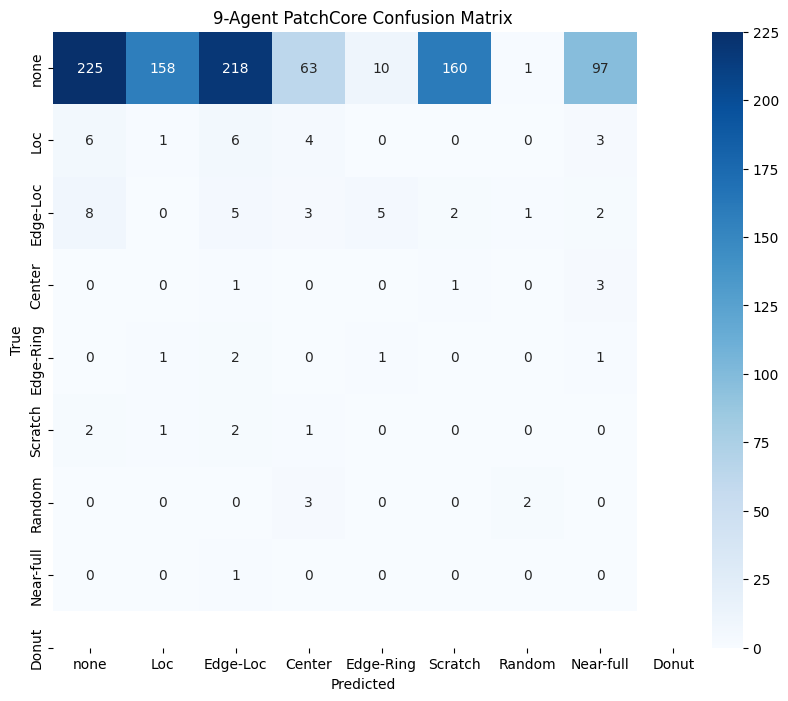

In [ ]:
print("Test Accuracy:", accuracy_score(all_tgts, all_preds))

cm = confusion_matrix(all_tgts, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('9-Agent PatchCore Confusion Matrix')
plt.show()